In [ ]:
import pandas as pd
import numpy as np
import csv
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighb-orsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
try:
    df = pd.read_csv("final_data2.csv",
                    sep=',',
                    on_bad_lines='skip',
                    engine='c',
                    quoting=csv.QUOTE_MINIMAL)
    print(f"Veri seti yüklendi. Satır sayısı: {len(df)}")
except:
    df = pd.read_csv("final_data2.csv", on_bad_lines='skip', engine='python')

Veri seti yüklendi. Satır sayısı: 20405


In [51]:
df

,title,label,clean_title,full_text,word_count,sentiment,subjectivity,lexical_div,caps_ratio,excl_count
0,"The 2018 Holiday Gift For Your Partner, Based ...",0,2018 holiday gift partner based zodiac sign,"Since we're in the midst of Hanukkah, and Chri...",859.0,0.193464,0.513658,0.544820,0.022732,1.0
1,Gen-Z Takes The MTV Movie & TV Awards Red Carp...,0,genz takes mtv movie awards red carpet storm,Entertainment\n\nHow Michaela Coel Pulled Off ...,37.0,0.000000,0.000000,1.000000,0.086207,0.0
2,Look What You Made Me Do,0,look made,"2017 single by Taylor Swift\n\n""Look What You ...",5396.0,0.095222,0.403197,0.372683,0.036833,4.0
3,Selena Gomez Wore 6 Outfits in 1 Day — But She...,0,selena gomez wore outfits day loved date night...,Selena Gomez and the Weeknd stepped out for da...,320.0,0.125938,0.390296,0.621875,0.049025,0.0
4,Eric Roberts,0,eric roberts,(1956-)\n\nSynopsis\n\nActor Eric Roberts was ...,747.0,0.018087,0.346635,0.519411,0.049755,1.0
...,...,...,...,...,...,...,...,...,...,...
20400,Ashton Kutcher Blows Kiss to John McCain Durin...,1,ashton kutcher blows kiss john mccain senate h...,Actor Ashton Kutcher sent a little love to Sen...,444.0,0.056250,0.457143,0.621622,0.028169,0.0
20401,"Islamic State's Baghdadi, in undated audio, ur...",1,islamic states baghdadi undated audio urges mi...,CAIRO (Reuters) - Islamic State leader Abu Bak...,560.0,0.017294,0.268190,0.573214,0.034994,0.0
20402,Senators say effort to protect 'Dreamers' maki...,1,senators say effort protect dreamers making pr...,WASHINGTON (Reuters) - A bipartisan push in th...,639.0,0.034516,0.432459,0.575900,0.032997,0.0
20403,Nordic states step up defense cooperation beca...,1,nordic states step defense cooperation russia ...,HELSINKI (Reuters) - Nordic countries agreed o...,338.0,0.013095,0.314105,0.618343,0.044536,0.0


In [ ]:
features = ['word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count']

Bağımsız değişkenlerimiz olacak feature'larımızı belirledik

In [ ]:
satir_once = len(df)

In [ ]:
df = df.dropna(subset=features + ['label']) # varsa boş label verilerini temizliyoruz

In [ ]:
satir_sonra = len(df)
temizlenen_sayisi = satir_once - satir_sonra

print(f"Temizlenen (NaN içeren) Satır Sayısı: {temizlenen_sayisi}")
print(f"Kalan Temiz Satır Sayısı: {satir_sonra}")
print(df['label'].value_counts())

Temizlenen (NaN içeren) Satır Sayısı: 2
Kalan Temiz Satır Sayısı: 20403
label
0    10454
1     9949
Name: count, dtype: int64


Temizlikten sonra veri kaybetmediğimizi görmüş olduk.

In [ ]:
X = df[features] # bağımsız değişkenler
y = df['label'].astype(int)   # bağımlı değişkenimiz

Şimdi sınıflandırma için ölçeklendirme yapmamız gerekiyor.

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

Modelin doğruluğunu kanıtlamak için K-Fold Cross Validation yapacağız, 10 parçaya yapıp sonuçları görelim

In [ ]:
models = {  # modellerimiz için şuan optimal değerleri bilmeden çalıştıracağız
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [ ]:
print("\n--- 10-Fold Cross Validation Sonuçları (K=10) ---")
for name, model in models.items():
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    print(f"{name:20}: Ortalama Başarı (Accuracy) = %{scores.mean()*100:.2f}")


--- 10-Fold Cross Validation Sonuçları (K=10) ---
Logistic Regression : Ortalama Başarı (Accuracy) = %72.51
K-Nearest Neighbors : Ortalama Başarı (Accuracy) = %72.58
Random Forest       : Ortalama Başarı (Accuracy) = %79.05


Aldığımız sonuçlara göre en yüksek accuracy oranına sahip model % 79.05 ile random forest modeli. Karmaşık feature'ların arasındaki ilişkiyi diğerlerinden daha iyi kurduğunu gösteriyor.Bu modellerin başarısını arttırmak için optimize edip en uygun K değerlerini bulabiliriz.

KNN Modelinin başarısını arttırmak için elbow method u kullanacağız.

In [ ]:
k_values = range(1, 21) # k nin değer aralığı
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())  # skorların ortalamasını alarak en iyisini buluruz





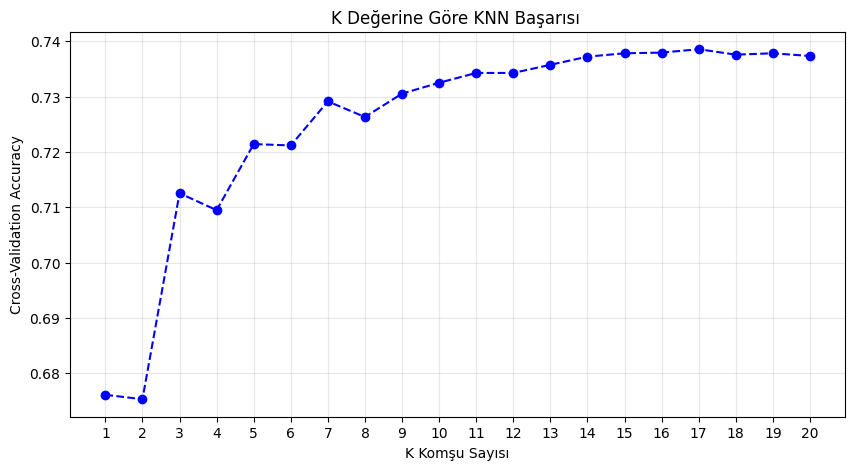

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, k_scores, marker='o', linestyle='--', color='blue')
plt.title('K Değerine Göre KNN Başarısı ')
plt.xlabel('K Komşu Sayısı')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

Elbow method ile edindiğimiz grafiğe göre en yüksek başarı oranını veren K = 17 oluyor

In [ ]:
best_k = k_values[np.argmax(k_scores)]
print(f"En iyi K değeri: {best_k} (Başarı: %{max(k_scores)*100:.2f})")

En iyi K değeri: 17 (Başarı: %73.86)


Ve K = 17 KNN için % 73.86 oranında başarı veriyor, yaklaşık %1 lik bir artış oldu

In [38]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=17),   # bu sefer en yakın 17 komşuya gidiyoruz
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [39]:
print("\n--- 10-Fold Cross Validation Sonuçları (K=10) ---")
for name, model in models.items():
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    print(f"{name:20}: Ortalama Başarı (Accuracy) = %{scores.mean()*100:.2f}")


--- 10-Fold Cross Validation Sonuçları (K=10) ---
Logistic Regression : Ortalama Başarı (Accuracy) = %72.51
K-Nearest Neighbors : Ortalama Başarı (Accuracy) = %73.78
Random Forest       : Ortalama Başarı (Accuracy) = %79.05


Doğrulamış olduk. Başarı artışının az olması KNN in en yakın birkaç komşudan 17 komşuya geçtiğinde etraftaki noise'i biraz daha iyi temizliyor ve model daha geniş bir perspektife baktığından sağduyulu hale geliyor.

Random Forest optimizasyonu yapmak için Grid Search Kullanabiliriz. Modelin performansını üst düzeye çıkaran parametreleri deneme yanılma ile bulur ve tüm parametre kombinasyonlarını tek tek deneyerek en tutarlı sonucu verir.

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"En İyi RF Parametreleri: {grid_search.best_params_}")

En İyi RF Parametreleri: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


En iyi random forest parametrelerini edindik

Logistic Regression için de en iyi C değerini bularak optimizasyon yapabiliriz

In [41]:
# Logistic Regression Optimizasyonu
param_grid_lr = {'C': [0.1, 1, 10, 100], 'penalty': ['l2']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
print(f"LR için en iyi C değeri: {grid_lr.best_params_['C']}")

LR için en iyi C değeri: 100


Edindiğimiz optimize değerlerle tekrar modelleri deniyoruz

In [42]:
best_lr = LogisticRegression(C=100, max_iter=1000)
best_knn = KNeighborsClassifier(n_neighbors=17) # elbow dan gelen k = 17

final_models = {
    "Optimized Logistic Reg": best_lr,
    "Optimized KNN (K=17)": best_knn,
    "Optimized Random Forest": best_rf  # önceden elde etmiştik
}

In [43]:
print("\n--- OPTİMİZE EDİLMİŞ MODELLERİN KARŞILAŞTIRMALI BAŞARISI ---")
for name, model in final_models.items():
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    print(f"{name:25}: Ortalama Accuracy = %{scores.mean()*100:.2f} (+/- {scores.std()*100:.2f})")


--- OPTİMİZE EDİLMİŞ MODELLERİN KARŞILAŞTIRMALI BAŞARISI ---
Optimized Logistic Reg   : Ortalama Accuracy = %74.82 (+/- 0.61)
Optimized KNN (K=17)     : Ortalama Accuracy = %73.78 (+/- 1.09)
Optimized Random Forest  : Ortalama Accuracy = %79.21 (+/- 0.90)


Çok fazla artış sağlamasa da hepsinde artış sağlandı, artış büyüklüğü sırası

KNN > Logistic Regression > Random Forest

olarak görülüyor.

Şimdi tahmin sonuçlarımızı Confusion Matrix ile görelim

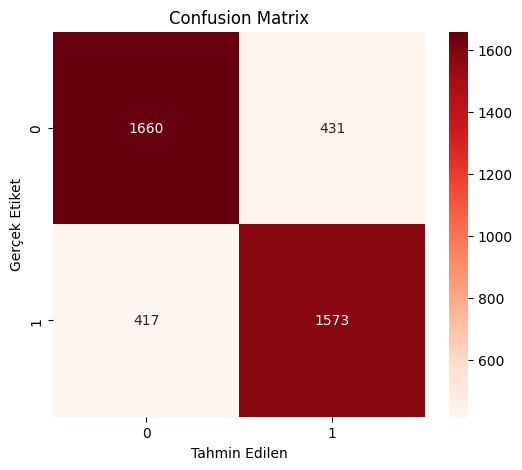


--- FINAL SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      2091
           1       0.78      0.79      0.79      1990

    accuracy                           0.79      4081
   macro avg       0.79      0.79      0.79      4081
weighted avg       0.79      0.79      0.79      4081



In [52]:
# En iyi modeli yani random forest'ı test setinde çalıştırıyoruz
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen')
plt.show()

print("\n--- FINAL SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred))

Şuanki Sınıflandırma sonuçlarımıza göre, model gerçek haberler için % 80 ve yalan haberler için % 78 precision yani keskinlik oranına sahip.Tahmin yüzdesi olarak düşünebiliriz ve yüksek diyebiliriz.

Duyarlılık(recall) oranları ikisinde de % 80, demek bu ki sahte haberlerin yüzde seksenini yakalayabiliyoruz aslında.

F1 Score da da %1 lik farkla gerçek haberler daha yüksekte.Arada büyük bir fark olmadığı için modelin dengeli olduğunu söyleyebiliyoruz.

Ayrıca accuracy, macro average, ve weighted average'e baktığımızda:

Macro average, real ve fake sınıflarının sayılarına eşitmiş gibi davranır ve önemlerini eşit tutar.

Weighted average da,sınıfları büyüklüklerine yani supportlarına göre ağırlıklı ortalama alır,ikisinde de yaklaşık olarak eşit sayıda veri olduğu için değerler birbirine çok yakın çıkıyor.


Bu modellerin ROC Eğrilerini çizdirerek ayırt etme ve tahmin başarılarını daha net görebiliriz.

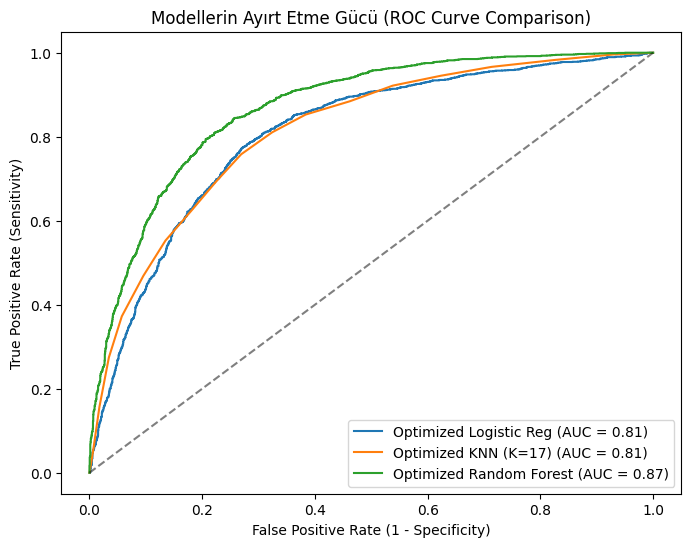

In [45]:
plt.figure(figsize=(8,6))
for name, model in final_models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Modellerin Ayırt Etme Gücü (ROC Curve Comparison)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend()
plt.show()

Görüldüğü gibi True Positive oran'a en yakın eğri random forest eğrisi. Çok yüksek olmasa da 0.87 gibi bir değer ile yeterince elverişli bir model. Lojistik regresyon ve KNN de 0.81 ile iyi sayılabilecek seviyedeler.

Lojistik Regresyonda modelin hangi bağımsız değişkene ne kadar inandığını görebiliriz, bu sayede hangi özellik sahte haberlerde daha çok ayırt edici onu anlayabiliriz.

FEATURE WEIGHTS

/tmp/ipython-input-980991437.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')


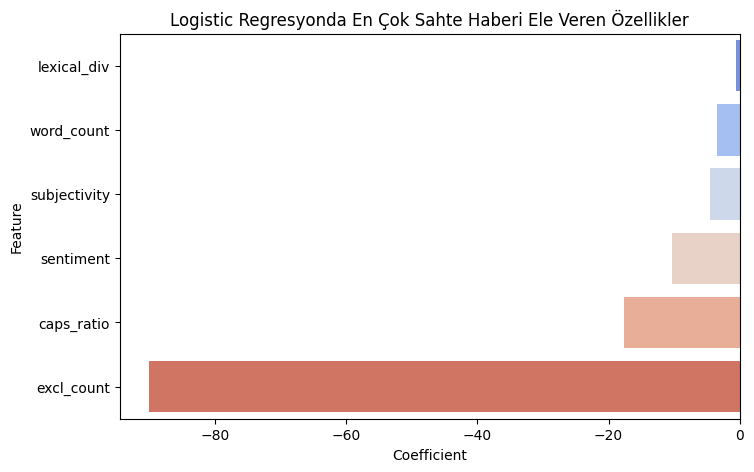

In [53]:
best_lr.fit(X_train, y_train)
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': best_lr.coef_[0]})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.title('Logistic Regresyonda En Çok Sahte Haberi Ele Veren Özellikler')
plt.show()

Lojistik regresyonda en çok sahte haberi ele veren katsayıyı bulabiliyoruz.Bu grafiğe baktığımızda, negatif katsayısı daha az olan özellik daha gerçek bir haber olduğuna işaret eder. Yani ne kadar negatif ise o kadar yalan haberde vardır, ne kadar 0 a yakınsa gerçek haberde vardır yorumunu yapabiliriz. Aslında şöyle, burada en negatifte bulunan özelliklerden mesela caps_ratio arttıkça yalan haber olma olasılığı sentiment'in artmasından daha fazla olur diyebiliriz. Ayrıca lojistik regresyon doğrusallık aradığı için, sentiment sahte haberi bulma konusunda en yararlı özellik olsa da sentiment arttıkça yalan haber olma ihtimali artar konusuna geldiğimzde o doğrusallık bulunmadığı için en çok ele veren özellik sentiment olur diyemiyoruz.

MODELLERİN KARŞILAŞTIRILMASI

/tmp/ipython-input-1553740380.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(final_scores.keys()), y=list(final_scores.values()), palette='viridis')


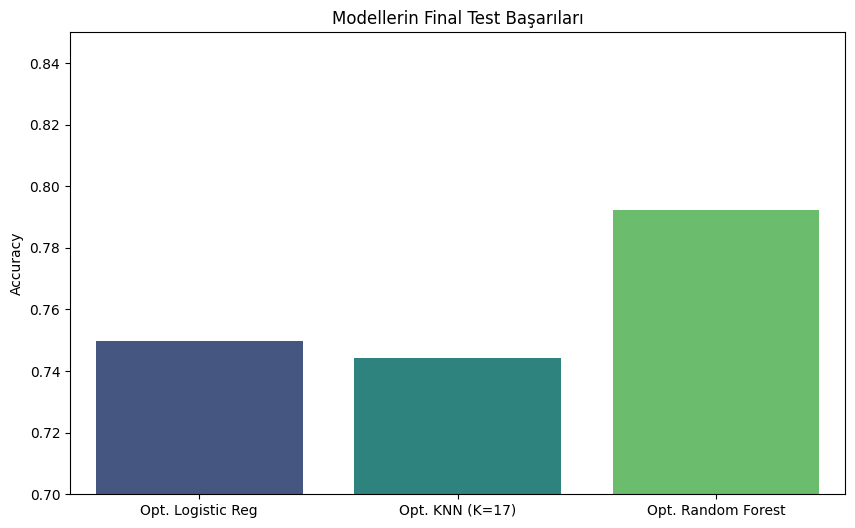

In [55]:
final_scores = {
    "Opt. Logistic Reg": accuracy_score(y_test, best_lr.predict(X_test)),
    "Opt. KNN (K=17)": accuracy_score(y_test, KNeighborsClassifier(n_neighbors=17).fit(X_train, y_train).predict(X_test)),
    "Opt. Random Forest": accuracy_score(y_test, best_rf.predict(X_test))
}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(final_scores.keys()), y=list(final_scores.values()), palette='viridis')
plt.ylim(0.70, 0.85)
plt.title('Modellerin Final Test Başarıları')
plt.ylabel('Accuracy')
plt.show()


Modellerin başarısını görselleştirdiğimize Random Forest açık ara daha fazla başarı oranına sahip, ardından da Logistic Regression ve KNN geliyor.

Az önce Negatif Katsayı örneğindeki gibi, tekrar grafik ile hangi özniteliğin en çok sahte haber tespiti yapmada etkili olduğunu görebiliriz.

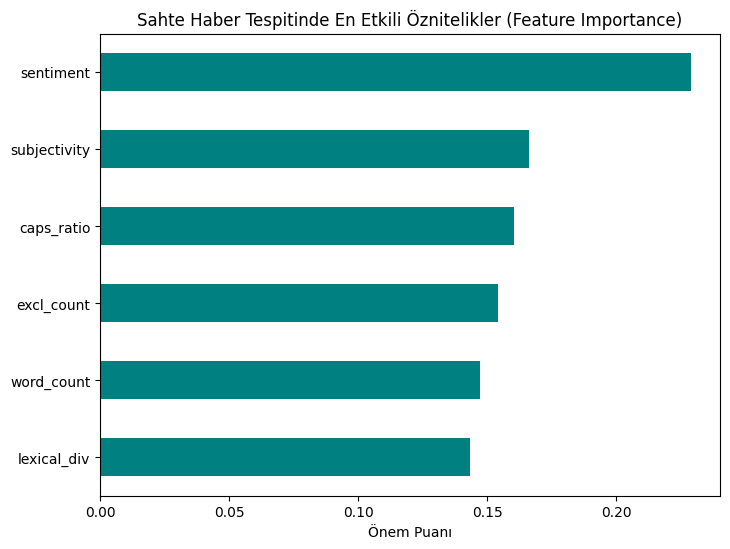

In [47]:
importances = best_rf.feature_importances_
feat_importances = pd.Series(importances, index=features)

plt.figure(figsize=(8,6))
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('Sahte Haber Tespitinde En Etkili Öznitelikler (Feature Importance)')
plt.xlabel('Önem Puanı')
plt.show()

Bu grafiğe göre sentiment yani duygusallık, yalan haberlerde en çok bulunan değil ama tespitte en çok işe yarayan özellik.Yani özellikler karar verirken ne kadar faydalı olduğuna göre sıralanıyor.Sentiment'in ardından kişisellik(öznellik) yani subjectivity geliyor. Ondan sonra da caps ratio yani büyük harf kullanımı geliyor. Genel olarak büyük harfle dikkat çekmeye çalışan haberlerin yalan olduğu düşünürdüm ben de

Burdan sonraki kısımda, elimizdeki modellerin başarı oranlarını yani accuracy yüzdelerini arttırmak için verisetimize ekstra özellikler ekleyeceğiz ve şuankiler dışında farklı modellerde de deneyerek en iyi ve optimal çalışan modeli bulmaya çalışacağız.

GENEL OLARAK NOTEBOOK ÖZETİ:

Özellik Seçimi: İlk 6 temel stilometrik özellik (word_count, sentiment, subjectivity, lexical_div, caps_ratio, excl_count) model girişi olarak seçilir.

Baseline Modeller: Logistic Regression, KNN ve Random Forest modelleri varsayılan parametrelerle eğitilir.

Performans Ölçümü: 10-Fold Cross-Validation (Çapraz Doğrulama) yapılarak modellerin ortalama başarısı hesaplanır.

Değerlendirme: Sınıflandırma raporları (Precision, Recall, F1) ve Confusion Matrix (Hata Matrisi) ile modellerin ilk performansları kaydedilir.

